Paths configured successfully.

FILE INFORMATION
   TIFF  : fig4_perceptual_metrics.tiff             (21.87 MB)
   PNG   : fig4_perceptual_metrics.png              (12.76 MB)
   PDF   : fig4_perceptual_metrics.pdf              (1.61 MB)

 Figura 4 regenerada con calidad de publicación
   • TIFF 300 DPI (color) + LZW: 
   • Tamaño optimizado: 


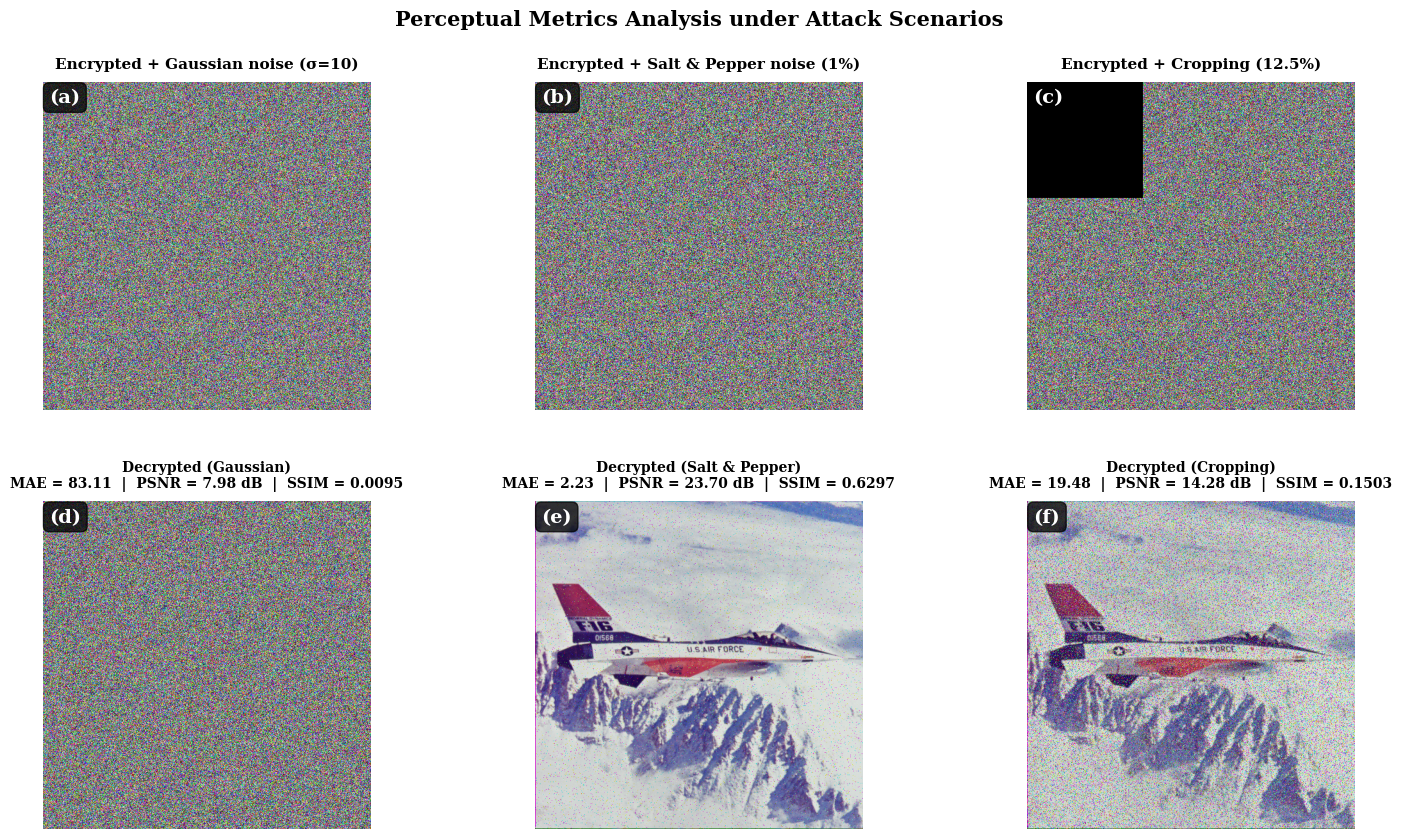

In [2]:
"""
DyS-CNN: Figure 4 (Perceptual Metrics) - OPTIMIZED for publication
300 DPI (T&F standard for color images), LZW compression.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from PIL import Image
from google.colab import drive
from skimage.metrics import structural_similarity as ssim


# Clone the repository if running directly in Colab.
if not os.path.exists('DySCNN') and not os.path.exists('.git'):
    !git clone https://github.com/gaussluis/DySCNN.git
    %cd DySCNN
elif os.path.exists('DySCNN'):
    %cd DySCNN

# Define paths relative to the repository folder
PATH_INPUT = "data/input_images"
PATH_RESULTS = "results"
SBOX_FILE = os.path.join(PATH_RESULTS, "sbox_fixed_seed42.npy")

print("Paths configured successfully.")

# Publication-quality settings
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['font.size'] = 12

sbox = np.load(SBOX_FILE)
sbox_inv = np.argsort(sbox).astype(np.uint8)

# [Encryption/decryption/attack/metric functions — same as before]
def diffusion_forward(img):
    flat = img.flatten(); accum = 0
    out = np.zeros_like(flat, dtype=np.uint8)
    for i in range(len(flat)):
        accum = (accum + int(flat[i])) % 256; out[i] = accum
    return out.reshape(img.shape).astype(np.uint8)

def diffusion_inverse(img):
    flat = img.flatten(); prev = 0
    out = np.zeros_like(flat, dtype=np.uint8)
    for i in range(len(flat)):
        out[i] = (int(flat[i]) - prev) % 256; prev = int(flat[i])
    return out.reshape(img.shape).astype(np.uint8)

def round_encrypt(img, sbox, seed):
    h, w, c = img.shape
    img_sub = sbox[img]
    np.random.seed(seed)
    indices = np.random.permutation(h * w * c)
    img_perm = img_sub.flatten()[indices].reshape(h, w, c)
    np.random.seed(seed)
    key = np.random.randint(0, 256, (h, w, c), dtype=np.uint8)
    return diffusion_forward(np.bitwise_xor(img_perm, key))

def round_decrypt(img, sbox_inv, seed):
    h, w, c = img.shape
    img_xor = diffusion_inverse(img)
    np.random.seed(seed)
    key = np.random.randint(0, 256, (h, w, c), dtype=np.uint8)
    img_perm = np.bitwise_xor(img_xor, key)
    np.random.seed(seed)
    indices = np.random.permutation(h * w * c)
    flat = img_perm.flatten()[np.argsort(indices)]
    return sbox_inv[flat.reshape(h, w, c)]

def encrypt_image(img, sbox, seed1=42, seed2=43):
    img = img.astype(np.uint8)
    return round_encrypt(round_encrypt(img, sbox, seed1), sbox, seed2)

def decrypt_image(img_enc, sbox_inv, seed1=42, seed2=43):
    img = img_enc.astype(np.uint8)
    return round_decrypt(round_decrypt(img, sbox_inv, seed2), sbox_inv, seed1)

def apply_gaussian_noise(img, sigma=10):
    noise = np.random.normal(0, sigma, img.shape).astype(np.int32)
    return np.clip(img.astype(np.int32) + noise, 0, 255).astype(np.uint8)

def apply_salt_pepper(img, prob=0.01):
    img_noisy = img.copy()
    mask = np.random.random(img.shape[:2]) < prob
    salt = np.random.choice([0, 255], size=img.shape[:2])
    img_noisy[mask] = np.stack([salt[mask]] * 3, axis=-1)
    return img_noisy

def apply_cropping(img, pct=0.125):
    h, w, c = img.shape
    cs = int(np.sqrt(pct * h * w))
    out = img.copy(); out[:cs, :cs, :] = 0
    return out

def calculate_mae(a, b): return np.mean(np.abs(a.astype(float) - b.astype(float)))
def calculate_psnr(a, b):
    mse = np.mean((a.astype(float) - b.astype(float)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255 ** 2 / mse)
def calculate_ssim(a, b): return ssim(a, b, channel_axis=2, data_range=255)

# Load and process
img_original = np.array(Image.open(os.path.join(PATH_INPUT, "airplane.png")).convert('RGB'))
img_encrypted = encrypt_image(img_original, sbox)

img_gauss_enc = apply_gaussian_noise(img_encrypted, sigma=10)
img_sp_enc = apply_salt_pepper(img_encrypted, prob=0.01)
img_crop_enc = apply_cropping(img_encrypted, pct=0.125)

img_gauss_dec = decrypt_image(img_gauss_enc, sbox_inv)
img_sp_dec = decrypt_image(img_sp_enc, sbox_inv)
img_crop_dec = decrypt_image(img_crop_enc, sbox_inv)

m_gauss = calculate_mae(img_original, img_gauss_dec); p_gauss = calculate_psnr(img_original, img_gauss_dec); s_gauss = calculate_ssim(img_original, img_gauss_dec)
m_sp = calculate_mae(img_original, img_sp_dec);       p_sp = calculate_psnr(img_original, img_sp_dec);       s_sp = calculate_ssim(img_original, img_sp_dec)
m_crop = calculate_mae(img_original, img_crop_dec);   p_crop = calculate_psnr(img_original, img_crop_dec);   s_crop = calculate_ssim(img_original, img_crop_dec)

# Figure
fig = plt.figure(figsize=(15, 9))
gs = GridSpec(2, 3, figure=fig, top=0.87, bottom=0.04,
              left=0.02, right=0.98, wspace=0.08, hspace=0.28)

fig.text(0.5, 0.94, "Perceptual Metrics Analysis under Attack Scenarios",
         ha='center', va='center', fontsize=15, fontweight='bold')

row1 = [(img_gauss_enc, "Encrypted + Gaussian noise (σ=10)", "(a)"),
        (img_sp_enc, "Encrypted + Salt & Pepper noise (1%)", "(b)"),
        (img_crop_enc, "Encrypted + Cropping (12.5%)", "(c)")]

for i, (im, t, lab) in enumerate(row1):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(im); ax.set_title(t, fontsize=11, fontweight='bold', pad=10); ax.axis('off')
    ax.text(0.02, 0.98, lab, transform=ax.transAxes, fontsize=14, fontweight='bold',
            va='top', ha='left', color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.75))

row2 = [(img_gauss_dec, f"Decrypted (Gaussian)\nMAE = {m_gauss:.2f}  |  PSNR = {p_gauss:.2f} dB  |  SSIM = {s_gauss:.4f}", "(d)"),
        (img_sp_dec,    f"Decrypted (Salt & Pepper)\nMAE = {m_sp:.2f}  |  PSNR = {p_sp:.2f} dB  |  SSIM = {s_sp:.4f}", "(e)"),
        (img_crop_dec,  f"Decrypted (Cropping)\nMAE = {m_crop:.2f}  |  PSNR = {p_crop:.2f} dB  |  SSIM = {s_crop:.4f}", "(f)")]

for i, (im, t, lab) in enumerate(row2):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(im); ax.set_title(t, fontsize=10, fontweight='bold', pad=10); ax.axis('off')
    ax.text(0.02, 0.98, lab, transform=ax.transAxes, fontsize=14, fontweight='bold',
            va='top', ha='left', color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.75))

# Save: 300 DPI for color figures (T&F standard), LZW compression for TIFF
ruta_tiff = os.path.join(PATH_RESULTS, "fig4_perceptual_metrics.tiff")
ruta_png = os.path.join(PATH_RESULTS, "fig4_perceptual_metrics.png")
ruta_pdf = os.path.join(PATH_RESULTS, "fig4_perceptual_metrics.pdf")

fig.savefig(ruta_tiff, dpi=300, format='tiff',
            bbox_inches='tight', pad_inches=0.15,
            facecolor='white', pil_kwargs={"compression": "tiff_lzw"})

fig.savefig(ruta_png, dpi=300, format='png',
            bbox_inches='tight', pad_inches=0.15,
            facecolor='white', pil_kwargs={"optimize": True})

fig.savefig(ruta_pdf, format='pdf',
            bbox_inches='tight', pad_inches=0.15, facecolor='white')

print("\n" + "=" * 70)
print("FILE INFORMATION")
print("=" * 70)
for ruta, fmt in [(ruta_tiff, 'TIFF'), (ruta_png, 'PNG'), (ruta_pdf, 'PDF')]:
    size_mb = os.path.getsize(ruta) / (1024 * 1024)
    print(f"   {fmt:<6}: {os.path.basename(ruta):<40} ({size_mb:.2f} MB)")

print("\n Figura 4 regenerada con calidad de publicación")
print("   • TIFF 300 DPI (color) + LZW: ")
print("   • Tamaño optimizado: ")
print("=" * 70)

plt.show()
plt.close()